In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("data.csv")
df.head(3)

,Order_ID,Date,Category,Price_USD,Quantity,Discount_Pct,Payment_Method,Region,Rating
0,1001,2026-01-05,Laptops,1200.0,1,0.05,Credit Card,Europe,4.8
1,1002,2026-01-06,Smartphones,800.0,2,0.10,PayPal,North America,4.5
2,1003,2026-01-08,Audio,150.0,3,0.00,Credit Card,Europe,4.2


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        75 non-null     int64  
 1   Date            75 non-null     object 
 2   Category        75 non-null     object 
 3   Price_USD       75 non-null     float64
 4   Quantity        75 non-null     int64  
 5   Discount_Pct    75 non-null     float64
 6   Payment_Method  75 non-null     object 
 7   Region          75 non-null     object 
 8   Rating          75 non-null     float64
dtypes: float64(3), int64(2), object(4)
memory usage: 5.4+ KB


In [26]:
df.value_counts('Category')

Category
Smartphones    16
Accessories    15
Audio          15
Laptops        15
Tablets        14
Name: count, dtype: int64

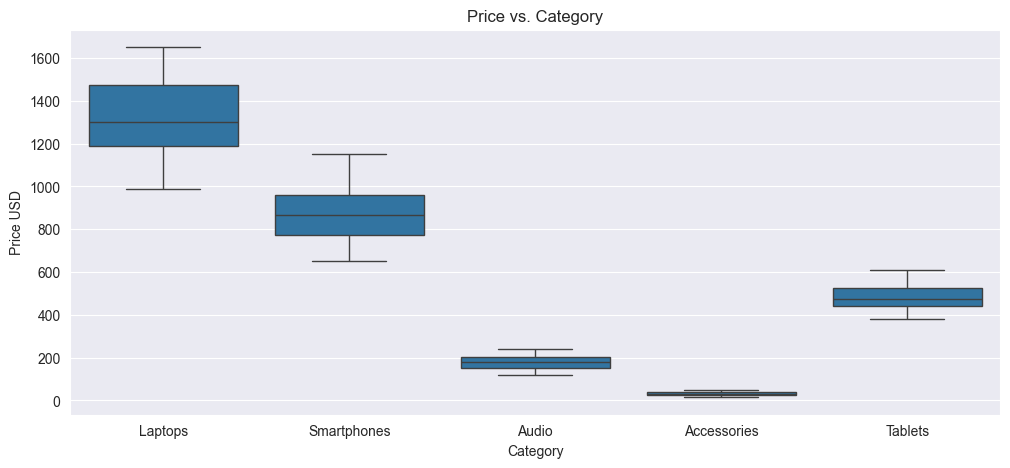

In [27]:
# Розподіл цін за категоріями
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x="Category", y="Price_USD")
plt.title("Price vs. Category")
plt.xlabel('Category')
plt.ylabel('Price USD')
plt.show()

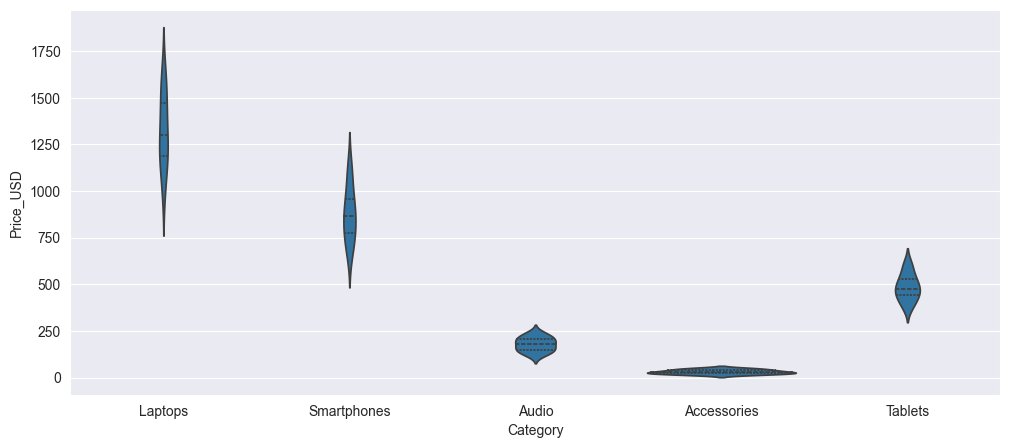

In [28]:
plt.figure(figsize=(12,5))
sns.violinplot(data=df, x="Category", y="Price_USD", inner="quartile")
plt.show()

In [29]:
df.head(3)

,Order_ID,Date,Category,Price_USD,Quantity,Discount_Pct,Payment_Method,Region,Rating
0,1001,2026-01-05,Laptops,1200.0,1,0.05,Credit Card,Europe,4.8
1,1002,2026-01-06,Smartphones,800.0,2,0.10,PayPal,North America,4.5
2,1003,2026-01-08,Audio,150.0,3,0.00,Credit Card,Europe,4.2


<Axes: xlabel='Category'>

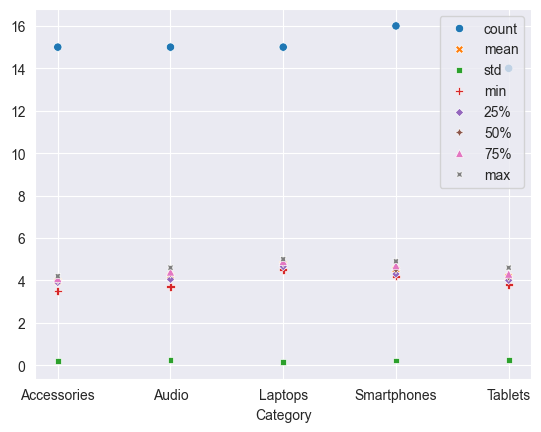

In [30]:
relationship = df.groupby('Category')['Rating'].describe()
sns.scatterplot(relationship)

<Axes: xlabel='Price_USD', ylabel='Rating'>

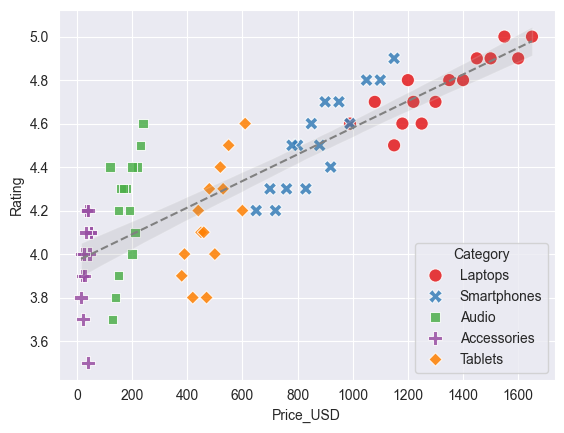

In [31]:
sns.scatterplot(
    data=df,
    x="Price_USD",
    y="Rating",
    hue="Category",
    style="Category",
    s=90,
    alpha=0.85,
    palette="Set1",
)

sns.regplot(
    data=df,
    x="Price_USD",
    y="Rating",
    scatter=False,
    color="gray",
    line_kws={"linestyle": "--", "linewidth": 1.5, "label": "Лінія тренду"},
)

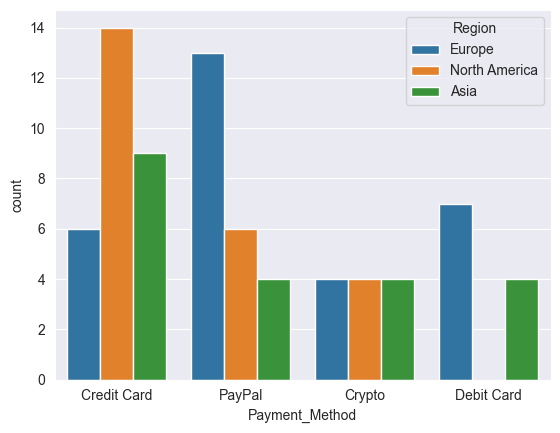

In [32]:
sns.countplot(
    data=df,
    x="Payment_Method",
    hue="Region",
)
plt.show()

In [33]:
crosstab = pd.crosstab(df["Payment_Method"], df["Region"])
print(crosstab)

Region          Asia  Europe  North America
Payment_Method                             
Credit Card        9       6             14
Crypto             4       4              4
Debit Card         4       7              0
PayPal             4      13              6


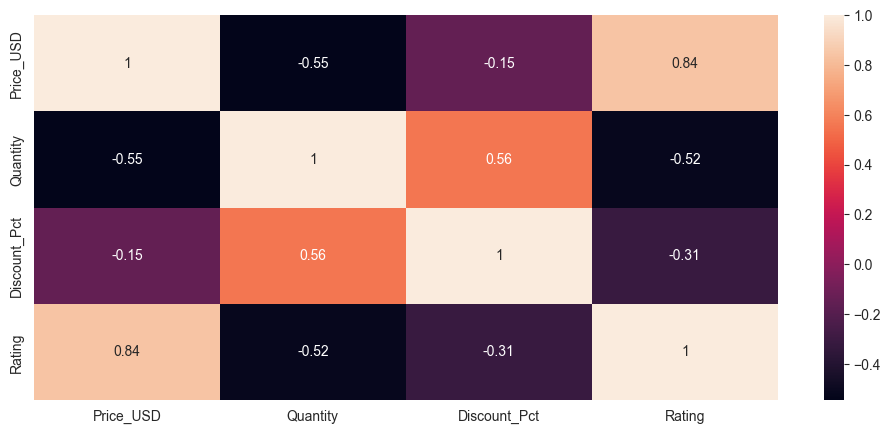

In [34]:
a = df.select_dtypes('number').drop('Order_ID',axis=1).corr()
plt.figure(figsize=(12,5))
sns.heatmap(a, annot=True)
plt.show()

_______________

In [35]:
df.head()

,Order_ID,Date,Category,Price_USD,Quantity,Discount_Pct,Payment_Method,Region,Rating
0,1001,2026-01-05,Laptops,1200.0,1,0.05,Credit Card,Europe,4.8
1,1002,2026-01-06,Smartphones,800.0,2,0.10,PayPal,North America,4.5
2,1003,2026-01-08,Audio,150.0,3,0.00,Credit Card,Europe,4.2
3,1004,2026-01-10,Accessories,25.0,5,0.15,Crypto,Asia,3.9
4,1005,2026-01-12,Smartphones,950.0,1,0.00,Credit Card,North America,4.7


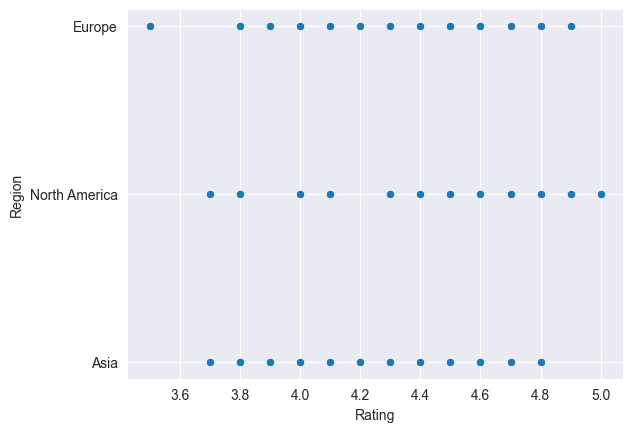

In [36]:
sns.scatterplot(x=df['Rating'], y=df['Region'])
plt.show()

<Axes: xlabel='Payment_Method', ylabel='Rating'>

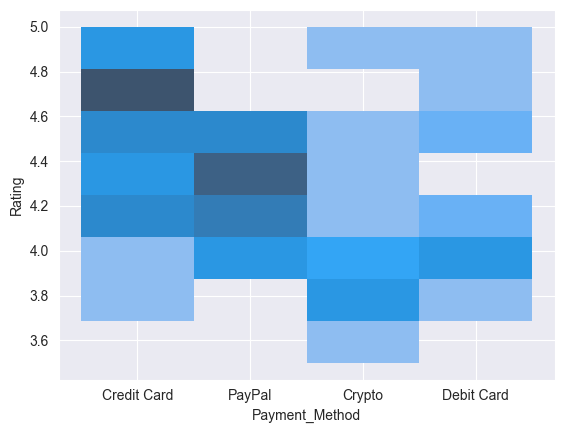

In [37]:
sns.histplot(x=df['Payment_Method'],y=df['Rating'],)

In [38]:
df['Total_Price_USD'] = df['Price_USD'] * df['Quantity']
df.head()

,Order_ID,Date,Category,Price_USD,Quantity,Discount_Pct,Payment_Method,Region,Rating,Total_Price_USD
0,1001,2026-01-05,Laptops,1200.0,1,0.05,Credit Card,Europe,4.8,1200.0
1,1002,2026-01-06,Smartphones,800.0,2,0.10,PayPal,North America,4.5,1600.0
2,1003,2026-01-08,Audio,150.0,3,0.00,Credit Card,Europe,4.2,450.0
3,1004,2026-01-10,Accessories,25.0,5,0.15,Crypto,Asia,3.9,125.0
4,1005,2026-01-12,Smartphones,950.0,1,0.00,Credit Card,North America,4.7,950.0


<Axes: xlabel='Total_Price_USD', ylabel='Region'>

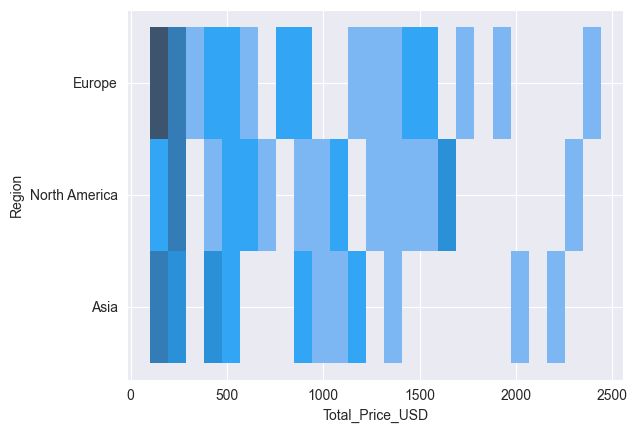

In [44]:
sns.histplot(x=df['Total_Price_USD'], y=df['Region'], bins=25)